# 08 — UMAP (direction only)

Requires `pip install umap-learn`. Subsample for speed.


### UMAP on unit directions only

**Method:** Same subsampling idea as `07`, but input is only the **4D** normalized direction vectors (no κ or radius).

**How to read the output:** If the plot looks very similar to `07`, radial/scalar information may be redundant for this nonlinear view of angular structure. Large differences suggest κ/radius carry extra degrees of freedom not visible in direction-only UMAP.


c:\Users\john\Documents\philipp\papermap\.conda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


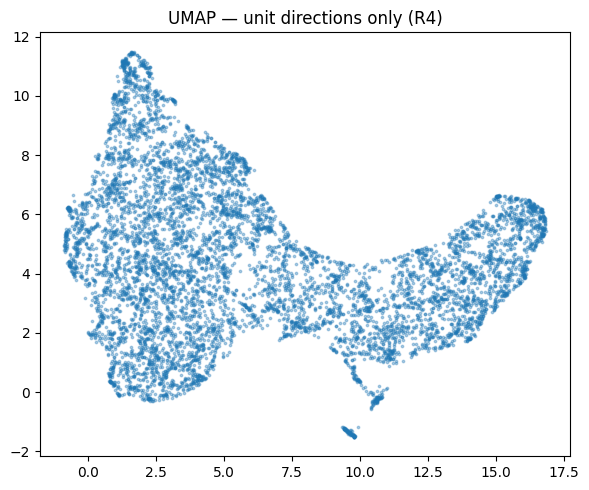

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import umap

import dmercator3d_io as dm

merged = dm.load_merged_parquet(Path("cache/merged.parquet"))
rng = np.random.default_rng(43)
n = min(8000, len(merged))
idx = rng.choice(len(merged), size=n, replace=False)
sub = merged.iloc[idx].reset_index(drop=True)
U = dm.normalize_direction_nd(sub)
red = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=43).fit_transform(U)
plt.figure(figsize=(6, 5))
plt.scatter(red[:, 0], red[:, 1], s=3, alpha=0.35)
plt.title("UMAP — unit directions only (R4)")
plt.tight_layout()
plt.show()
